In [1]:
%load_ext autoreload
%autoreload 2
import sys
from matplotlib.lines import Line2D
from csbdeep.utils import normalize

sys.path.append("..")
from src import *

2025-12-03 15:39:43.959917: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-03 15:39:44.103811: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-03 15:39:44.953586: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Cupy Available= 1


In [40]:
dataset = "synthetic"
variant = 150
methods = ["cellpose", "stardist"]
datas = ["Noisy", "DeepCAD-RT", "Freq2Clean"]
meta = DATASETS[dataset]

In [44]:
df = pd.DataFrame(columns=["data", "method", "iou"])
for method in methods:
    ious_x = pd.read_json(f"{method}_results/{dataset}/x/ious.json", typ="series")
    ious_dcad = pd.read_json(f"{method}_results/{dataset}/deepcad_{variant}/ious.json", typ="series")
    ious_f2c = pd.read_json(f"{method}_results/{dataset}/fft_{variant}/ious.json", typ="series")
    for data, ious in zip(datas, [ious_x, ious_dcad, ious_f2c]):
        for iou in ious:
            df.loc[len(df)] = (data, method, iou)

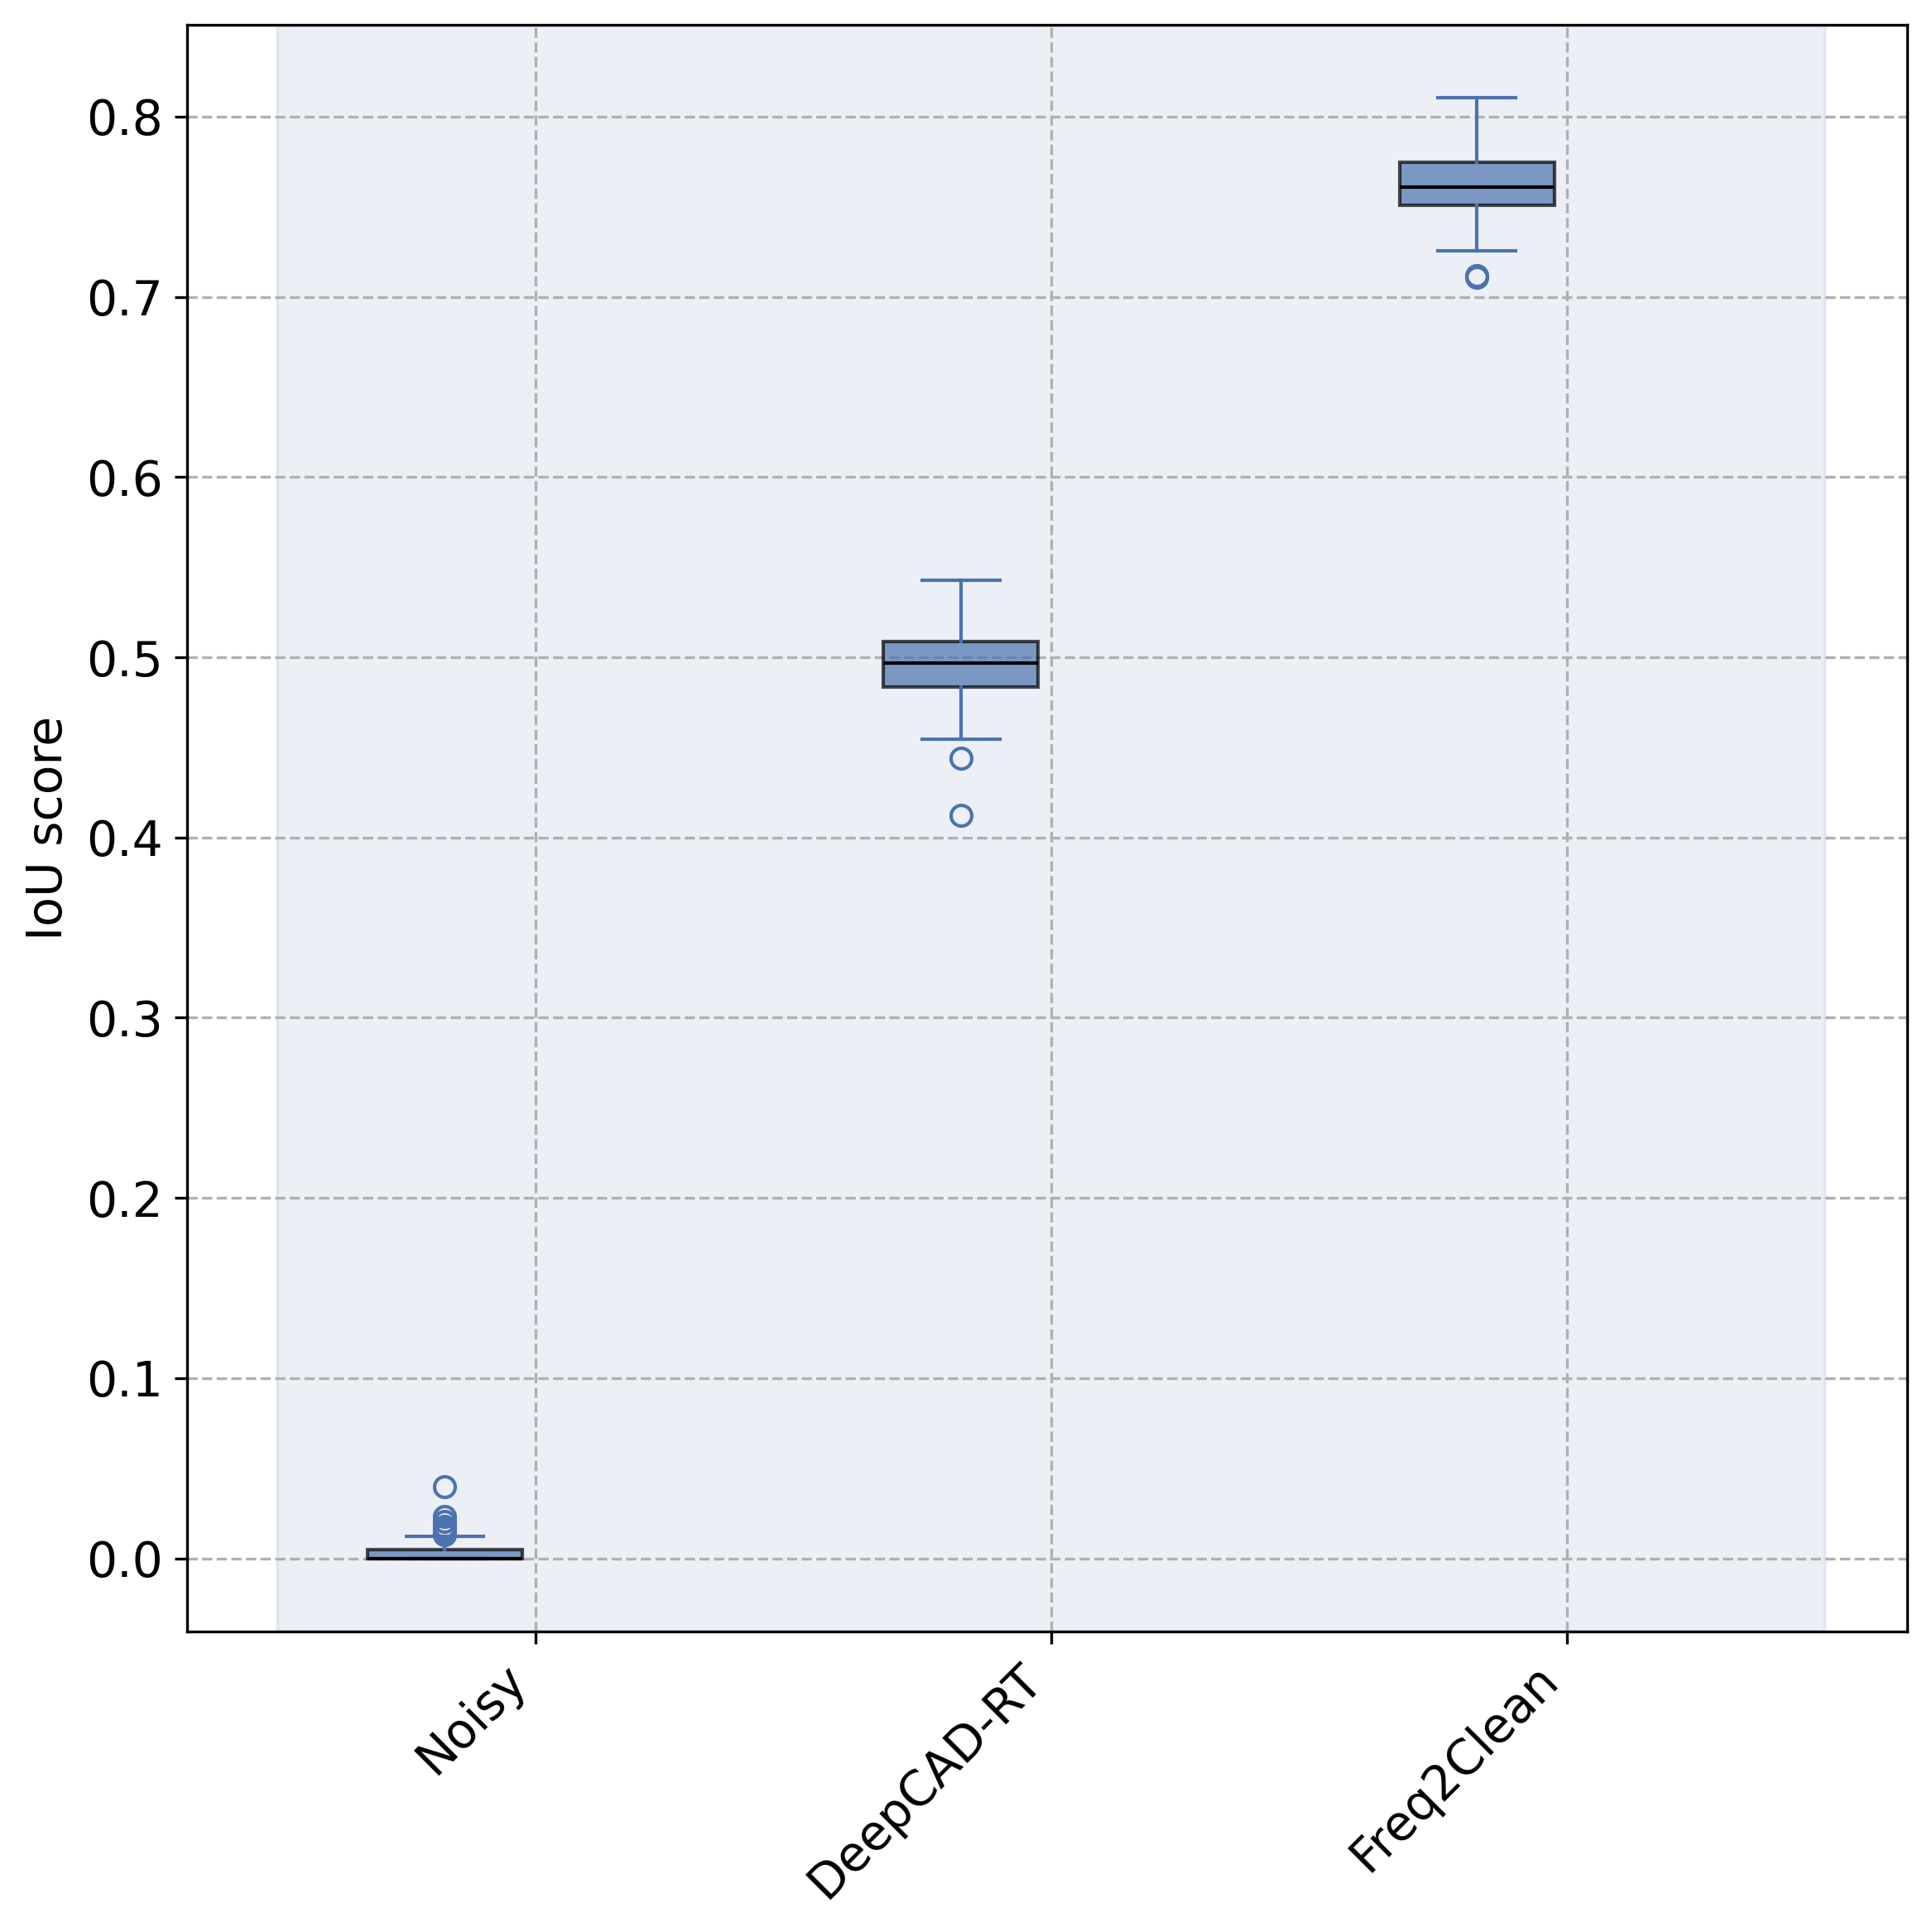

In [46]:
fig, ax = plt.subplots(figsize=(8, 8), dpi=300)

width = 0.35
x = np.arange(len(datas))
cellpose_positions = x - width / 2
stardist_positions = x + width / 2

# Plot boxplots manually for matching style
def plot_boxplots(ax, positions, values, label, color):
    bp = ax.boxplot(
        values,
        positions=positions,
        widths=0.3,
        patch_artist=True,
        boxprops=dict(facecolor=color, alpha=0.7),
        medianprops=dict(color="black"),
        whiskerprops=dict(color=color),
        capprops=dict(color=color),
        flierprops=dict(markeredgecolor=color),
    )
    return bp


# Collect data for each model
cellpose_data = [
    df[(df["method"] == "cellpose") & (df["data"] == m)]["iou"].values for m in datas
]
stardist_data = [
    df[(df["method"] == "stardist") & (df["data"] == m)]["iou"].values for m in datas
]

plot_boxplots(ax, cellpose_positions, cellpose_data, "Cellpose", "#4C72B0")
# plot_boxplots(ax, stardist_positions, stardist_data, "Stardist", "#DD8452")

# Add shading between models
ax.axvspan(-0.5, len(datas) - 0.5, color="#4C72B0", alpha=0.1)

ax.set_xticks(x)
ax.set_xticklabels(datas, rotation=45, ha="right")
ax.set_ylabel("IoU score")
# ax.set_title("Cellpose                     Stardist")

plt.tight_layout()
plt.show()